I've run two iterations of the FEAST model this week: the first one was a working version of the code that we had from RTI; the second one was a short run of a re-written version of the FEAST code that corrects some weird issues, re-workes the LDAR Programs, and sets up a simple attempt at a satellite program. This code is to work through Loading the JSON files and figuing out 1. how to pull out the info we need, 2. confirm that we got the LDAR programs set up correctly, metadatawise. 

In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import json
with open('Run_Results/realization0.json') as f:
    res = json.load(f)

Ah - The Jupyternotebook runs out of the file it's saved in. So it can't pull from 'EPA_Trial_Run/...', it has to run through 'Run_Results...' Great. Lets also load in the 

In [29]:
import json
with open('Run_Results_Rewrite/realization2.json') as f:
    runresults = json.load(f)

In [9]:
runresults.keys()

dict_keys(['quarterly_ogi', 'periodic', 'periodic_annual', 'satellite', 'satellite_annual', 'Null', 'time'])

re-making the timeseries plot from the original tutorial

In [26]:
# The color set defined here is the Tableau 10 color set.
color_set = np.array([
    [78, 121, 167],
    [242, 142,  43],
    [225,  87,  89],
    [118, 183, 178],
    [89, 161,  79],
    [237, 201, 72],
    [176, 122, 161],
    [255, 157, 167],
    [156, 117,  95],
    [186, 176, 172]
]) /255


quarterly_ogi
periodic
periodic_annual
satellite
satellite_annual
no LDAR


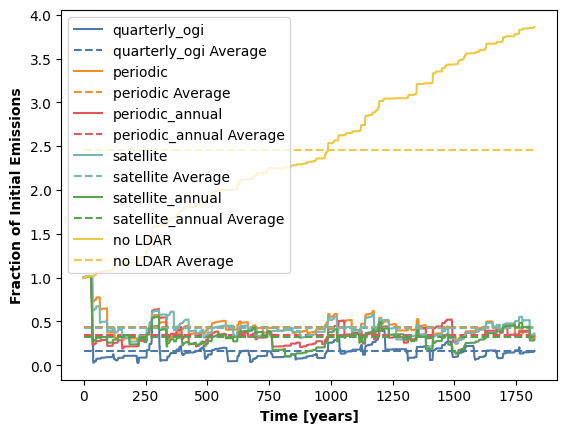

In [30]:
fig = plt.figure()
ax = fig.add_subplot(111)
counter = -1
 
for i in runresults.keys():
    lab = i #set the legend 
    #skip time and also set null to no LDAR
    if i.lower() == "null":
        lab = "no LDAR"
    if i.lower() == "time":
        break
    counter += 1
    print(lab)
    ax.plot(np.array(range(0,runresults['time']['n_timesteps'])), 
            np.array(runresults[i]['emission timeseries']) / runresults["Null"]['emission timeseries'][0], 
            label=lab, color=color_set[counter])
    
    avg_emissions = np.mean(np.array(runresults[i]['emission timeseries'])  / runresults["Null"]['emission timeseries'][0])
    ax.plot([0,runresults['time']['n_timesteps']],np.array([avg_emissions, avg_emissions]), '--', label = lab + ' Average', color = color_set[counter])

    

plt.xlabel('Time [years]', fontweight = 'bold')
plt.ylabel('Fraction of Initial Emissions', fontweight = 'bold')
plt.legend(bbox_to_anchor=(1, 0.72))
plt.legend()

In [24]:
print (color_set[0])

[ 78 121 167]


Lets redo that same plot but with aboslute emissions...

quarterly_ogi
periodic
periodic_annual
satellite
satellite_annual
no LDAR


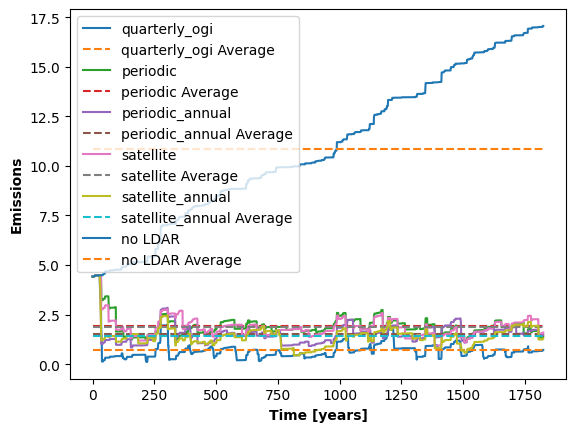

In [31]:
fig = plt.figure()
ax = fig.add_subplot(111)

 
for i in runresults.keys():
    lab = i #set the legend 
    #skip time and also set null to no LDAR
    if i.lower() == "null":
        lab = "no LDAR"
    if i.lower() == "time":
        break
    print(lab)
    ax.plot(np.array(range(0,runresults['time']['n_timesteps'])), 
            np.array(runresults[i]['emission timeseries']) , 
            label=lab)
    
    avg_emissions = np.mean(np.array(runresults[i]['emission timeseries']) )
    ax.plot([0,runresults['time']['n_timesteps']],np.array([avg_emissions, avg_emissions]), '--', label = lab + ' Average')

    

plt.xlabel('Time [years]', fontweight = 'bold')
plt.ylabel('Emissions', fontweight = 'bold')
plt.legend(bbox_to_anchor=(1, 0.72))
plt.legend()

Alright, thats all good - we can load different versions etc, but that's a single iterations version of the plot. What I /need/ are the average and variance of a bunch of different runs. To do that, I need to be able to load data into a multistructured data object...lets see how that works. Pulled Solution from: https://stackoverflow.com/questions/30539679/python-read-several-json-files-from-a-folder 

In [ ]:
import os, json
import pandas as pd

path_to_json = 'Run_Results_Rewrite/'
json_files = [pos_json for pos_json in os.listdir(path_to_json) if pos_json.endswith('.json')]
print(json_files) 

['realization0.json', 'realization10.json', 'realization12.json', 'realization14.json', 'realization16.json', 'realization18.json', 'realization2.json', 'realization4.json', 'realization6.json', 'realization8.json']


Okay, that pulled the JSON Files; order doesn't matter, so we just need to loop over and write them to a large file...

In [39]:
print(range(len(json_files)))

range(0, 10)


Just checking how to load JSON files here: 

In [ ]:
with open('Run_Results_Rewrite/realization2.json') as f:
    runresults = json.load(f)

In [48]:
check = json.load(open('Run_Results_Rewrite/realization2.json'))

Okay, so loop over your JSON files and load; we'll load one at a time. 

In [ ]:
em_results = pd.DataFrame(columns=df.keys())
em_results = em_results.drop(columns=['time'])

In [95]:
for i in range(len(json_files)):
    read_file = 'Run_Results_Rewrite/' + str(json_files[i])
    df = json.load(open(read_file))
    
    if i == 0: #on the first iteration create the catch file for all iterations. 
        em_results = pd.DataFrame(columns=df.keys())
        em_results = em_results.drop(columns=['time'])

    #okay - individual file loaded; lets loop through each file and grab the average emissions for each LDAR program. 
    for j in df.keys():
        if j.lower() == "time": #skip the time object
            break
        #Calculate the average emissions value for the full time series for each LDAR Program: 
        avg_em = np.mean(np.array(df[j]['emission timeseries']))
        em_results.at[i, j] = avg_em
        

print(np.mean(em_results['quarterly_ogi']))
print(np.var(em_results['quarterly_ogi']))



0.8709496421431749
0.02219620352903774


In [76]:
df['quarterly_ogi'].keys()

dict_keys(['emission timeseries', 'vent timeseries', 'repair cost', 'ogi', 'ogi repair'])

Okay, very good - need to revisit the EPA Model code now to set up iterative generation of different thresholds. 

In [78]:
for j in df.keys():
    # print(j)
    # print(df[j].keys())
    # check = df[j]['emission timeseries']
    # check = df[j]['emission timeseries']

    print(np.mean(np.array(df[j]['emission timeseries']) ))

0.9271964465808061
2.0041435591906693
1.524703039653683
2.0038278218525867
1.693616348860258
12.386081468044368


KeyError: 'emission timeseries'